In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv(r"C:\Users\merve\Desktop\PythonProject\DecisionTreeStructures\LightGBM\LightGBMRegressor\24-medical_cost.csv")

In [3]:
df.head()

,Id,age,sex,bmi,children,smoker,region,charges
0,1,19,female,27.900,0,yes,southwest,16884.92400
1,2,18,male,33.770,1,no,southeast,1725.55230
2,3,28,male,33.000,3,no,southeast,4449.46200
3,4,33,male,22.705,0,no,northwest,21984.47061
4,5,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Id        1338 non-null   int64  
 1   age       1338 non-null   int64  
 2   sex       1338 non-null   object 
 3   bmi       1338 non-null   float64
 4   children  1338 non-null   int64  
 5   smoker    1338 non-null   object 
 6   region    1338 non-null   object 
 7   charges   1338 non-null   float64
dtypes: float64(2), int64(3), object(3)
memory usage: 83.8+ KB


In [5]:
#sex ve smoker değişkenlerini 1-0 haline çevireceğiz

In [6]:
df.describe()

,Id,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,669.500000,39.207025,30.663397,1.094918,13270.422265
std,386.391641,14.049960,6.098187,1.205493,12110.011237
min,1.000000,18.000000,15.960000,0.000000,1121.873900
25%,335.250000,27.000000,26.296250,0.000000,4740.287150
50%,669.500000,39.000000,30.400000,1.000000,9382.033000
75%,1003.750000,51.000000,34.693750,2.000000,16639.912515
max,1338.000000,64.000000,53.130000,5.000000,63770.428010


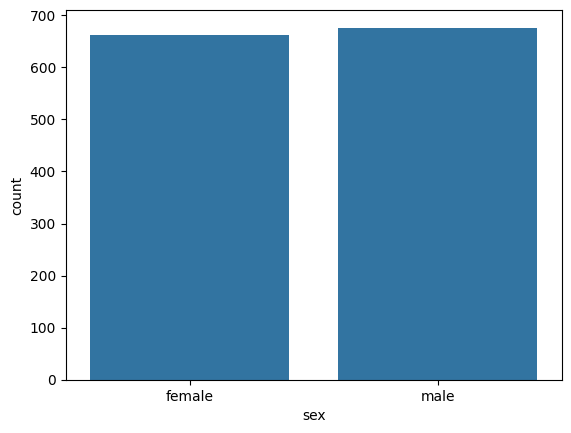

In [7]:
sns.countplot(data=df, x="sex")
plt.show()

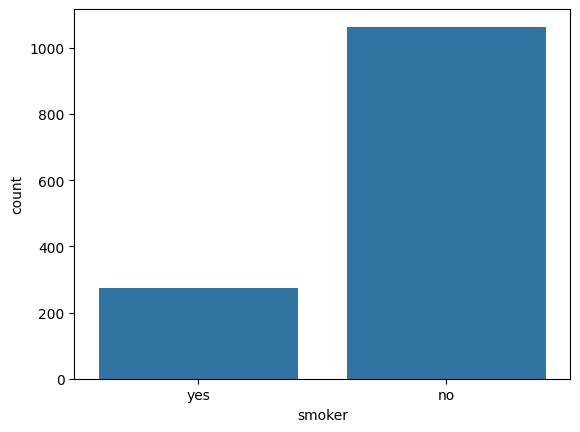

In [8]:
sns.countplot(data=df, x="smoker")
plt.show()

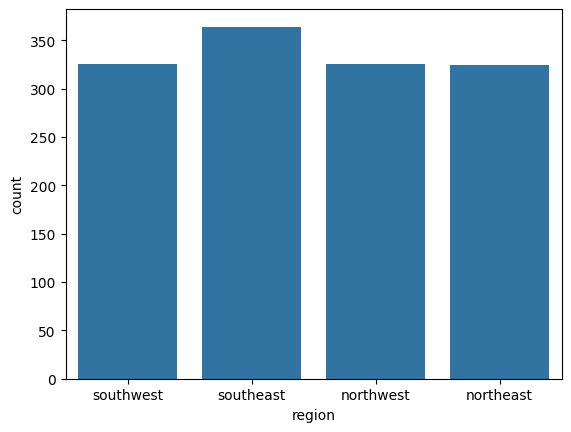

In [9]:
sns.countplot(data=df, x="region")
plt.show()

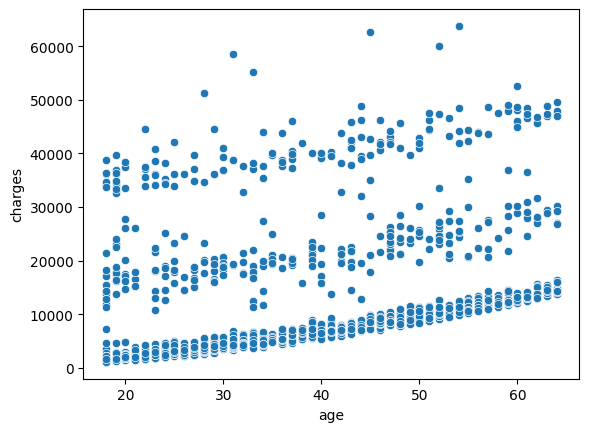

In [11]:
sns.scatterplot(data=df, x="age", y="charges")
plt.show()

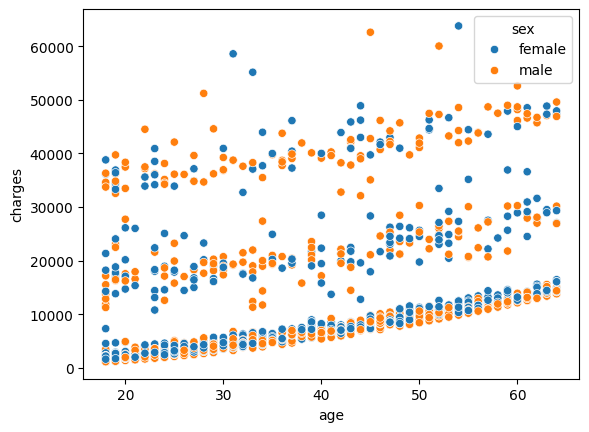

In [12]:
sns.scatterplot(data=df, x="age", y="charges", hue="sex")
plt.show()

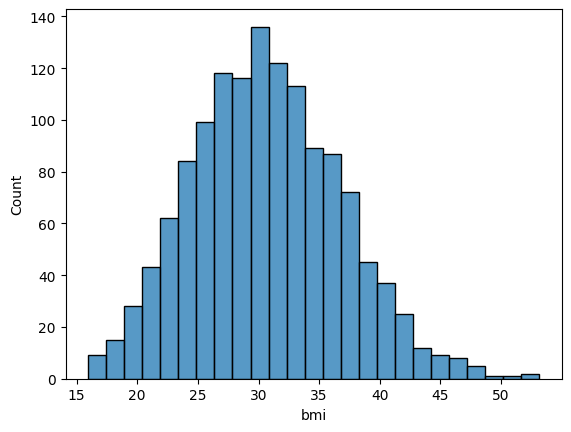

In [13]:
sns.histplot(data=df, x="bmi")
plt.show()

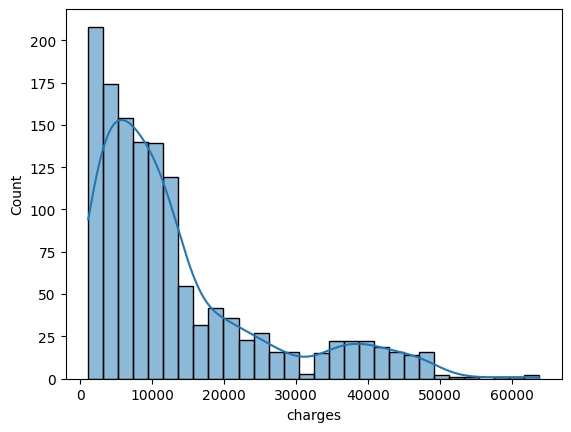

In [14]:
sns.histplot(data=df, x="charges" , kde=True)
plt.show()

In [15]:
#ıd'yi atacağız
df.drop("Id",inplace=True , axis=1)

In [16]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [17]:
df["sex"] = df["sex"].map({"male" : 0, "female": 1})
df["smoker"] = df["smoker"].map({"no" : 0, "yes": 1})

In [18]:
df["sex"].value_counts()

sex
0    676
1    662
Name: count, dtype: int64

In [19]:
df["smoker"].value_counts()

smoker
0    1064
1     274
Name: count, dtype: int64

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(4), object(1)
memory usage: 73.3+ KB


In [21]:
# one hot encoding -> region

In [22]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 15)

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
categorical_cols = ["region"]

preprocessor = ColumnTransformer(transformers=
                                [
                                    ('cat', OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
                                ], remainder= "passthrough"
                                )
                                 #(isim , hangi encoder kullanılacağı, hangi kolonların değişeceği )

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [25]:
X_train

array([[ 0.   ,  1.   ,  0.   , ..., 31.79 ,  2.   ,  1.   ],
       [ 0.   ,  0.   ,  1.   , ..., 29.1  ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   , ..., 27.36 ,  0.   ,  0.   ],
       ...,
       [ 0.   ,  1.   ,  0.   , ..., 24.42 ,  0.   ,  1.   ],
       [ 0.   ,  0.   ,  0.   , ..., 22.135,  2.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   , ..., 30.78 ,  3.   ,  0.   ]],
      shape=(1003, 8))

In [ ]:
from lightgbm import LGBMRegressor
model = LGBMRegressor()
#birçok zayıf karar ağacını birleştirip hatası çok düşük güçlü bir tahminleme modeli oluşturur,sayısal tahmin yapmak için kullanılır

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,000130 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 319
[LightGBM] [Info] Number of data points in the train set: 1003, number of used features: 8
[LightGBM] [Info] Start training from score 13374,181390


c:\Users\merve\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [27]:
from sklearn.metrics import r2_score, mean_squared_error
print(r2_score(y_pred, y_test))
print(mean_squared_error(y_pred, y_test))

0.8636669836215215
18458085.613847945


hyperparameter tuning

In [ ]:
param_grid = {
    "num_leaves" : [31, 50, 70],
    "max_depth" : [-1, 5, 10],
    "learning_rate" : [0.01, 0.05, 0.1],
    "n_estimators" : [100, 300, 1000],
    "min_child_samples" : [10,20,30], #bir yapraktaki en az veri sayısı
    "subsample" : [0.6, 0.8, 1.0], #Her ağaç eğitilirken verilerin yüzde kaçının kullanılacağı
    "colsample_bytree" : [0.6, 0.8, 1.0], #Her ağaçta özelliklerin yüzde kaçının kullanılacağı
    "reg_alpha" : [0, 0.5, 1.0], #Gereksiz özelliklerin etkisini tamamen sıfıra çeker , karmaşıklığı azaltır
    "reg_lambda" : [0, 0.5, 1.0] #değerleri küçülterek modelin daha istikrarlı kararlar verir 
}

In [31]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings("ignore")
random_search = RandomizedSearchCV(
    estimator=LGBMRegressor(verbosity=-1),
    param_distributions=param_grid,
    cv=5,
    verbose=0,
    random_state=15,
    scoring="neg_root_mean_squared_error",
    n_jobs = -1
)

In [32]:
random_search.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMRegressor(verbosity=-1)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [-1, 5, ...], 'min_child_samples': [10, 20, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strate

In [33]:
random_search.best_params_

{'subsample': 0.6,
 'reg_lambda': 1.0,
 'reg_alpha': 0.5,
 'num_leaves': 50,
 'n_estimators': 100,
 'min_child_samples': 30,
 'max_depth': -1,
 'learning_rate': 0.1,
 'colsample_bytree': 0.8}

In [34]:
y_pred=random_search.predict(X_test)

In [35]:
print(r2_score(y_pred, y_test))
print(mean_squared_error(y_pred, y_test))

0.8775521864086795
16446549.93278381


transformation deneyelim

In [ ]:
from scipy.stats import boxcox
y_train_transformed, lambda_y = boxcox(y_train)
#boxcox dönüşümü,bir tarafa yatkın verilerin normal dağılıma daha yakın hale gelmesini sağlar 

In [37]:
model = LGBMRegressor()
model.fit(X_train, y_train_transformed)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [38]:
model = LGBMRegressor()
model.fit(X_train, y_train_transformed)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [39]:
y_pred_transformed=model.predict(X_test)

In [ ]:
# (inverse Box-Cox) :boxcox() ile veriyi tanınmaz hale getirdikten sonra, aldığın sonuçları tekrar anlaşılır gerçek değerlere dönüştürür

def inverse_boxcox(y, lambda_):
    if lambda_ == 0:
        return np.exp(y)
    else:
        return np.power(y * lambda_ + 1, 1 / lambda_)

In [41]:
y_pred_original = inverse_boxcox(y_pred_transformed, lambda_y)
print(r2_score(y_pred_original, y_test))
print(mean_squared_error(y_pred_original, y_test))

0.8895535054323228
15470028.378876308


In [42]:
df_clean1=df.copy()
kayit_yolu = r"C:\Users\merve\Desktop\PythonProject\DecisionTreeStructures\LightGBM\LightGBMRegressor\cleaned_24-medical_cost.csv"
df_clean1.to_csv(kayit_yolu, index=False)
print(f"Temizlenmiş veri başarıyla kaydedildi: {kayit_yolu}")

Temizlenmiş veri başarıyla kaydedildi: C:\Users\merve\Desktop\PythonProject\DecisionTreeStructures\LightGBM\LightGBMRegressor\cleaned_24-medical_cost.csv
